In [1]:
import sys
sys.path.append('/dfs9/dmobley-lab/swapnilw/waterNES/')
import numpy as np
from pmx.analysis import read_dgdl_files

import pymbar
import pmx
import alchemlyb

from water_nes.analysis.free_energy_estimate import FreeEnergyEstimate
from water_nes.analysis.nes_free_energy import calculate_nes_free_energy
from alchemlyb.estimators import MBAR
from alchemlyb.parsing.gmx import extract_u_nk
from alchemlyb.postprocessors.units import get_unit_converter
from alchemlyb.preprocessing import slicing, statistical_inefficiency
from alchemlyb.visualisation import plot_mbar_overlap_matrix
from MDAnalysis import transformations as mda_transformations
from MDAnalysis.analysis import distances as mda_distances
from pymbar.timeseries import ParameterError
import matplotlib.pyplot as plt

import pandas as pd

/data/homezvol1/swapnilw/.conda/envs/simple_py37env/lib/python3.7/site-packages/MDAnalysis/coordinates/chemfiles.py:59: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  MIN_CHEMFILES_VERSION = LooseVersion("0.9")


In [23]:
p1t1="/dfs9/dmobley-lab/swapnilw/pdgfra_project/topology_tests/gag_gg/rbfe_gag_gg7/edge1/lambda_8/Production_MD/reduced_potentials/p1t1.xvg"
p1t2="/dfs9/dmobley-lab/swapnilw/pdgfra_project/topology_tests/gag_gg/rbfe_gag_gg7/edge1/lambda_8/Production_MD/reduced_potentials/p1t2.xvg"
p2t1="/dfs9/dmobley-lab/swapnilw/pdgfra_project/topology_tests/gag_gg/rbfe_gag_gg7/edge1/lambda_9/Production_MD/reduced_potentials/p2t1.xvg"
p2t2="/dfs9/dmobley-lab/swapnilw/pdgfra_project/topology_tests/gag_gg/rbfe_gag_gg7/edge1/lambda_9/Production_MD/reduced_potentials/p2t2.xvg"

In [42]:
p1t1="/dfs9/dmobley-lab/swapnilw/pdgfra_project/residue_deletion/test/p1t1.xvg"
p1t2="/dfs9/dmobley-lab/swapnilw/pdgfra_project/residue_deletion/test/p1t2.xvg"
p2t1="/dfs9/dmobley-lab/swapnilw/pdgfra_project/residue_deletion/test/p2t1.xvg"
p2t2="/dfs9/dmobley-lab/swapnilw/pdgfra_project/residue_deletion/test/p2t2.xvg"

In [43]:
#test run, the FE should be around 0.6 kcal/mol
#p1t1="/dfs9/dmobley-lab/swapnilw/openeye_colab/scytalone_dehydratase/C3d-C5d/amber14_openff2-oetoolkit/ligand_water_separate_3std/A/run11/stage1/prod/reduced_potentials/p1t1.xvg"
#p1t2="/dfs9/dmobley-lab/swapnilw/openeye_colab/scytalone_dehydratase/C3d-C5d/amber14_openff2-oetoolkit/ligand_water_separate_3std/A/run11/stage1/prod/reduced_potentials/p1t2.xvg"
#p2t1="/dfs9/dmobley-lab/swapnilw/openeye_colab/scytalone_dehydratase/C3d-C5d/amber14_openff2-oetoolkit/ligand_water_separate_3std/A/run11/stage2/prod/reduced_potentials/p2t1.xvg"
#p2t2="/dfs9/dmobley-lab/swapnilw/openeye_colab/scytalone_dehydratase/C3d-C5d/amber14_openff2-oetoolkit/ligand_water_separate_3std/A/run11/stage2/prod/reduced_potentials/p2t2.xvg"

In [44]:
mp1t1 = pd.read_csv(p1t1, skiprows=23, sep='\s+')
mp2t1 = pd.read_csv(p2t1, skiprows=23, sep='\s+')

mp1t2 = pd.read_csv(p1t2, skiprows=23, sep='\s+')
mp2t2 = pd.read_csv(p2t2, skiprows=23, sep='\s+')

rpf = mp2t1['s0']-mp1t1['s0']
#rpf = rpf[200:]

rpb = mp2t2['s0']-mp1t2['s0']
#rpb =rpb[200:]

In [45]:
mp1t1, mp2t1, mp1t2, mp2t2

(            @          s0  legend  Potential
 0         0.0  224.349380     NaN        NaN
 1        10.0  202.753220     NaN        NaN
 2        20.0  233.531311     NaN        NaN
 3        30.0  199.232758     NaN        NaN
 4        40.0  232.131378     NaN        NaN
 ...       ...         ...     ...        ...
 996    9960.0  217.328293     NaN        NaN
 997    9970.0  251.617783     NaN        NaN
 998    9980.0  234.480606     NaN        NaN
 999    9990.0  241.644699     NaN        NaN
 1000  10000.0  217.048584     NaN        NaN
 
 [1001 rows x 4 columns],
             @          s0  legend  Potential
 0         0.0  225.915787     NaN        NaN
 1        10.0  203.376450     NaN        NaN
 2        20.0  233.647766     NaN        NaN
 3        30.0  203.954132     NaN        NaN
 4        40.0  232.352631     NaN        NaN
 ...       ...         ...     ...        ...
 996    9960.0  217.747787     NaN        NaN
 997    9970.0  258.030243     NaN        NaN
 998  

In [46]:
#rpf = mp1t2['s0']-mp1t1['s0']
rpf = rpf.dropna()

#rpb = -1*(mp2t1['s0']-mp1t2['s0'])
rpb =rpb.dropna()

In [47]:
mp1t1[-10:], mp1t2[-10:], mp2t1[-10:], mp2t2[-10:]

(            @          s0  legend  Potential
 991    9910.0  222.425781     NaN        NaN
 992    9920.0  224.596649     NaN        NaN
 993    9930.0  221.595169     NaN        NaN
 994    9940.0  231.141266     NaN        NaN
 995    9950.0  235.764694     NaN        NaN
 996    9960.0  217.328293     NaN        NaN
 997    9970.0  251.617783     NaN        NaN
 998    9980.0  234.480606     NaN        NaN
 999    9990.0  241.644699     NaN        NaN
 1000  10000.0  217.048584     NaN        NaN,
         @          s0  legend  Potential
 80  800.0  266.653290     NaN        NaN
 81  810.0  222.773346     NaN        NaN
 82  820.0  263.706329     NaN        NaN
 83  830.0  230.949631     NaN        NaN
 84  840.0  221.363297     NaN        NaN
 85  850.0  225.892639     NaN        NaN
 86  860.0  211.295456     NaN        NaN
 87  870.0  235.678055     NaN        NaN
 88  880.0  248.433838     NaN        NaN
 89  890.0  199.700989     NaN        NaN,
             @          s0  le

In [48]:
rpf[-10:], rpb[-10:]

(991     0.594971
 992     0.127808
 993     1.738648
 994     1.688232
 995     4.808838
 996     0.419494
 997     6.412460
 998     2.626480
 999     0.000366
 1000    0.024902
 Name: s0, dtype: float64,
 80    0.050171
 81    0.095947
 82    0.214112
 83    0.012634
 84    0.117492
 85    0.011597
 86    0.841186
 87    5.453308
 88    1.733642
 89    0.025024
 Name: s0, dtype: float64)

In [49]:
rpf = np.array(rpf)
rpb = np.array(rpb)
rpf * 0.239006, rpb * 0.239006

(array([3.74380671e-01, 1.48955709e-01, 2.78334437e-02, ...,
        6.27744479e-01, 8.74761960e-05, 5.95172741e-03]),
 array([5.39675548e-04, 3.63351979e-01, 4.79938388e-02, 1.62215762e-02,
        2.26549007e-02, 5.10425994e-02, 4.68952956e-01, 4.59952707e-02,
        2.61228778e-02, 9.84680819e-03, 1.17387558e-01, 2.02215806e-01,
        5.40082814e-01, 4.51147726e-03, 9.07607121e-01, 7.80474810e-01,
        1.11013507e-02, 1.34338772e+00, 4.49347054e-01, 1.12559159e-01,
        2.08663471e-01, 2.11362088e-01, 9.96346702e-02, 1.69216248e-03,
        1.96263840e-01, 0.00000000e+00, 3.44563000e-02, 3.87741824e-02,
        3.82194495e-03, 4.90294518e-02, 1.85089592e-01, 5.16420264e-03,
        1.09802224e-01, 5.26472857e-02, 3.05890873e-01, 6.78038511e-02,
        1.48064217e-02, 6.32102514e-01, 2.18626914e-01, 5.11622219e-01,
        1.50263072e-03, 4.82111192e-01, 2.00729189e-02, 2.14185227e-02,
        6.28877367e-02, 7.20626991e-03, 5.84094813e-02, 2.15918020e-03,
        2.9336074

In [50]:
energy = pmx.estimators.BAR(rpf, rpb, 298.15)
energy.dg * 0.239006, energy.err * 0.239006

(0.23389618389958697, 0.00819787981079039)

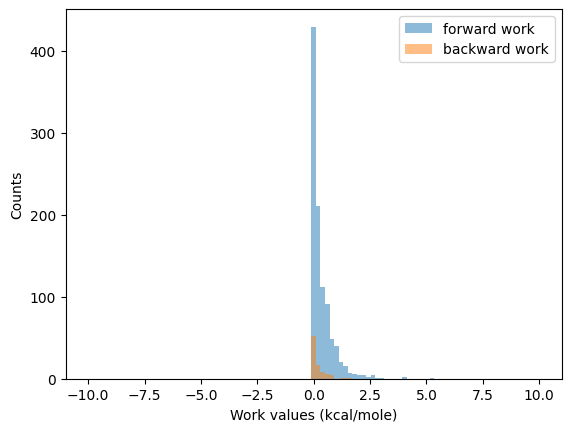

In [51]:
bins = np.linspace(-10, 10, 100)
plt.hist(rpf * 0.239006, bins, alpha=0.5, label='forward work')
plt.hist(rpb * 0.239006, bins, alpha=0.5, label='backward work')
plt.ylabel("Counts")
plt.xlabel("Work values (kcal/mole)")
plt.legend(loc='upper right')

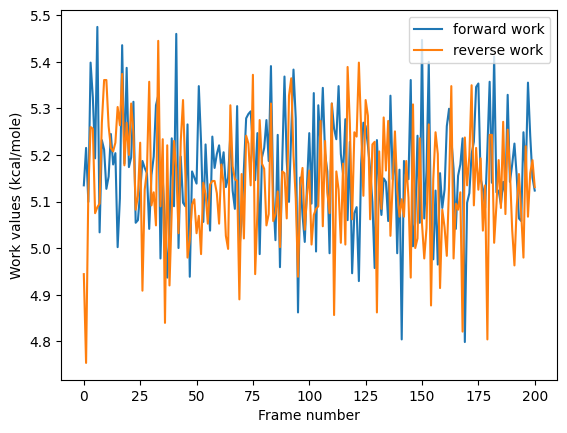

In [12]:
plt.plot(rpf * 0.239006, label="forward work")  #rpb = mp1t2['s0']-mp2t2['s0']
plt.plot(rpb * 0.239006, label="reverse work")
plt.xlabel("Frame number")
plt.ylabel("Work values (kcal/mole)")
plt.legend(loc='upper right')
#plt.ylim(-200, 5000)

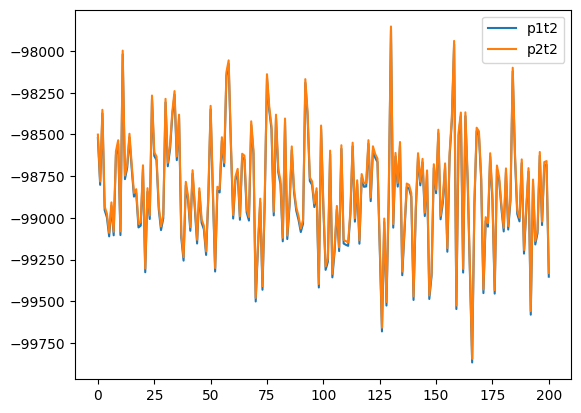

In [13]:
#plt.plot(mp1t1['s0'], label="p1t1")  #rpf = mp2t1['s0']-mp1t1['s0']
plt.plot(mp1t2['s0'], label="p1t2")  #rpb = mp1t2['s0']-mp2t2['s0']
#plt.plot(mp2t1['s0'], label="p2t1")
plt.plot(mp2t2['s0'], label="p2t2")
plt.legend(loc='upper right')


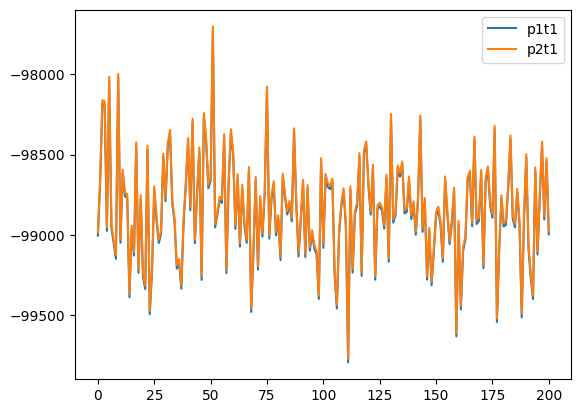

In [14]:
plt.plot(mp1t1['s0'], label="p1t1")  #rpf = mp2t1['s0']-mp1t1['s0']
#plt.plot(mp1t2['s0'], label="p1t2")  #rpb = mp1t2['s0']-mp2t2['s0']
plt.plot(mp2t1['s0'], label="p2t1")
#plt.plot(mp2t2['s0'], label="p2t2")
plt.legend(loc='upper right')
#plt.ylim(-100000, -95000)


In [15]:
energy = pmx.estimators.BAR(rpf, rpb, 298.15)
energy.dg * 0.239006, energy.err * 0.239006

(5.152512140929586, 0.00610018367299291)

In [22]:
#Complex_leg
delta_G_edge1 = 0.00217 + 1.336 + 1.9789 + 3.1779 + 5.8028 + 9.8564 + 8.8338 + 7.712 + 6.424 + 5.1614 + 3.926 + 2.724 + 1.5347 + 0.3267 + 0.0541 -0.02349
delta_G_edge1
#58.54 +- 0.6 kcal/mol for 0->15

delta_G_edge1_20ns = 0.0015 + 1.356 + 1.982 + 3.170 + 5.730 + 9.766 + 8.8755 + 7.740 + 6.435 + 5.152

delta_G_edge2 = 0.179

delta_G_edge3 = -69.750

delta_G_edge4 = 0.17

delta_G_complex = delta_G_edge1 + delta_G_edge2 + delta_G_edge3 + delta_G_edge4
delta_G_complex

-10.573619999999993

In [23]:
error_edge1 =      0.00037 + 0.01 + 0.0155 + 0.0259 + 0.0521 + 0.084 +  0.03 +  0.017 +  0.013 +  0.011 + 0.011 + 0.008 + 0.007 + 0.003 + 0.0018 + 0.001
error_edge1 = 0.29067

error_edge1_20ns = 0.0002 + 0.0044 + 0.0077 + 0.0144 + 0.032 + 0.045 +  0.016 + 0.0099 + 0.0077 + 0.006

error_edge2 = 0.02

error_edge3 = 0.2

error_edge4 = 0.02

error_complex = error_edge1 + error_edge2 + error_edge3 + error_edge4
error_complex

0.53067

In [18]:
#vacuum_leg
delta_G_edge1 = -3.2e-06 + 1.22 + 1.76 + 2.66 + 4.79 + 9.46 + 8.94 + 7.76 + 6.44 + 5.18 + 3.92 + 2.72 + 1.52 + 0.32 + 0.049 - 0.022
# 57.46 +- 0.4 kcal/mol for 0->15

delta_G_edge2 = 0.24

delta_G_edge3 = -73.164

delta_G_edge4 = 0.16

delta_G_vacuum = delta_G_edge1 + delta_G_edge2 + delta_G_edge3 + delta_G_edge4

delta_G_vacuum

-16.047003199999995

In [19]:
error_edge1 = 2.2e-06 + 0.01 + 0.02 + 0.04 + 0.05 + 0.06 + 0.02 + 0.02 + 0.01 + 0.01 + 0.01 + 0.009 + 0.008 + 0.004 + 0.002 + 0.002
error_edge1 = 0.2750022


error_edge2 = 0.029

error_edge3 = 0.195

error_edge4 = 0.0262

error_vacuum = error_edge1 + error_edge2 + error_edge3 + error_edge4

error_vacuum

0.5252022000000001

In [20]:
delta_G_complex - delta_G_vacuum, error_complex + error_vacuum

(5.4733832000000024, 1.0558722)

In [21]:
#Hydration FEs
GAG_solvent = 60.71 +- 0.26
GAG_vacuum = 33.27 +- 0.21
dG_hydration_GAG = 27.44 +- 0.47 kcal/mol

GG_solvent = 63.17 +- 0.22
GG_vacuum = 41.73 +- 0.04
dG_hydration_GG = 21.41 +- 0.26

ddG_GAG_GG = 6.03 +- 0.73

SyntaxError: invalid syntax (1652618511.py, line 4)